## 2 概述、线性代数和NDArray
### 2.1.1 向量点积a·b
#### a⋅b=2×1+(−1)×4+3×(−2)=2−4−6=−8



### 2.1.2 矩阵乘法A×B
$$
A \times B = 
\begin{bmatrix}
1 \times 2 + 0 \times 0 + 2 \times 3 & 1 \times 1 + 0 \times (-1) + 2 \times 2 \\
-1 \times 2 + 3 \times 0 + 1 \times 3 & -1 \times 1 + 3 \times (-1) + 1 \times 2
\end{bmatrix}
=
\begin{bmatrix}
8 & 5 \\
1 & -2
\end{bmatrix}
$$

结果形状: $\boldsymbol{2 \times 2}$

​
### 2.1.3 向量a的Frobenius范数

$$
\|\boldsymbol{a}\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{4 + 1 + 9} = \sqrt{14}
$$

In [ ]:
#2.2 编程题
import numpy as np

# 1. 创建形状为 (3,4) 的随机矩阵 X，服从标准正态分布
X = np.random.randn(3, 4)

# 2. 创建形状为 (4,2) 的全 1 矩阵 Y
Y = np.ones((4, 2))

# 3. 计算矩阵乘法 Z = X @ Y
Z = X @ Y

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
element = Z[0, 1]          # 第一行、第二列（索引从0开始）
row_2 = Z[1, :]            # 第二行
print("Z[0,1] =", element)
print("Z 的第 2 行:", row_2)

# 5. 计算 Z 的 Frobenius 范数
fro_norm = np.linalg.norm(Z, 'fro')
print("Z 的 Frobenius 范数:", fro_norm)

Z[0,1] = 0.7370179857310637
Z 的第 2 行: [-1.03873547 -1.03873547]
Z 的 Frobenius 范数: 1.803267540393862


## 3 概率与统计
### 3.1 真正患病的概率（使用贝叶斯公式）。
- $A$：患病，$P(A) = 0.001$
- $\overline{A}$：未患病，$P(\overline{A}) = 0.999$
- $B$：检测阳性
- $P(B|A) = 0.99,\ P(B|\overline{A}) = 0.02$

由贝叶斯公式：

$$
\begin{aligned}
P(A|B) &= \frac{P(B|A)P(A)}{P(B|A)P(A) + P(B|\overline{A})P(\overline{A})} \\
&= \frac{0.99 \times 0.001}{0.99 \times 0.001 + 0.02 \times 0.999} \\
&= \frac{0.00099}{0.00099 + 0.01998} \\
&= \frac{0.00099}{0.02097} \approx 4.72\%
\end{aligned}
$$

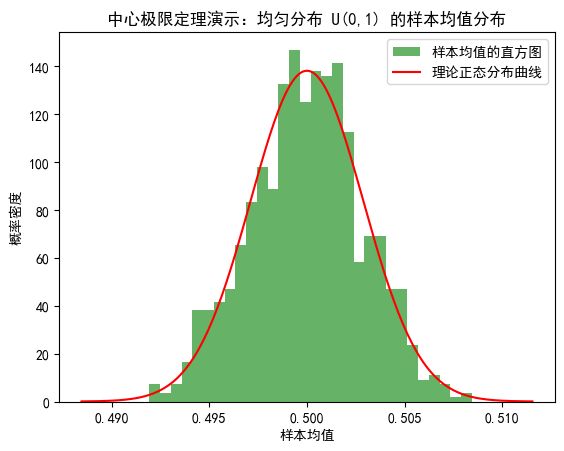

1000个样本均值的实际方差（自由度 9999）：0.000008
理论方差 1/(12×10000) = 0.000008


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置中文字体（防止乱码，可根据系统选择合适字体）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

np.random.seed(42)
n = 10000   # 每次样本量
m = 1000    # 重复次数

# 1. 生成 m 个样本均值
means = np.array([np.random.uniform(0, 1, n).mean() for _ in range(m)])

# 2. 绘制直方图并叠加理论正态分布曲线
plt.hist(means, bins=30, density=True, alpha=0.6, color='g', label='样本均值的直方图')

# 均匀分布 U(0,1) 的理论均值 = 0.5，方差 = 1/12，样本均值方差 = 1/(12n)
mu_theory = 0.5
sigma_theory = np.sqrt(1 / (12 * n))
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 200)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', label='理论正态分布曲线')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理演示：均匀分布 U(0,1) 的样本均值分布')
plt.legend()
plt.show()

# 3. 计算这些均值的实际方差
actual_var = np.var(means, ddof=1)   # 样本方差
print(f"1000个样本均值的实际方差（自由度 {n-1}）：{actual_var:.6f}")
print(f"理论方差 1/(12×{n}) = {1/(12*n):.6f}")

## 4 导数、反向传播和复杂度
已知 $z = (w_1 x_1 + w_2 x_2 - y)^2$，常数 $x_1 = 2, x_2 = 1, y = 3$。



#### 4.1.1. 偏导数表达式

$$
\begin{aligned}
\frac{\partial z}{\partial w_1} 
&= 2(w_1 x_1 + w_2 x_2 - y) \cdot x_1 \\
&= 2(2w_1 + w_2 - 3) \cdot 2 \\
&= 4(2w_1 + w_2 - 3)
\end{aligned}
$$

$$
\begin{aligned}
\frac{\partial z}{\partial w_2} 
&= 2(w_1 x_1 + w_2 x_2 - y) \cdot x_2 \\
&= 2(2w_1 + w_2 - 3) \cdot 1 \\
&= 2(2w_1 + w_2 - 3)
\end{aligned}
$$



#### 4.1.2. 给定 $w_1 = 0.5, w_2 = 1$ 时的梯度值

先计算：
$$
2w_1 + w_2 - 3 = 2 \times 0.5 + 1 - 3 = 1 + 1 - 3 = -1
$$

代入偏导数：
$$
\frac{\partial z}{\partial w_1} = 4 \times (-1) = -4, \quad \frac{\partial z}{\partial w_2} = 2 \times (-1) = -2

$$

In [ ]:
# 手动实现反向传播
import torch

# 1. 前向计算
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2

print("前向结果 L =", L)

# 2. 手动反向传播（链式法则）
dL_db = 2 * b
dL_dw2 = dL_db * 1        # = 2b
dL_da  = dL_db * 1        # = 2b
dL_dw1 = dL_da * x        # = 2b * x

# 直接打印浮点值，无需 .item()
print("手动梯度: dL/dw1 =", dL_dw1, ", dL/dw2 =", dL_dw2)

# 3. 验证 torch.autograd
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print("自动微分: dL/dw1 =", w1_t.grad.item(), ", dL/dw2 =", w2_t.grad.item())

前向结果 L = 12.25
手动梯度: dL/dw1 = 14.0 , dL/dw2 = 7.0
自动微分: dL/dw1 = 14.0 , dL/dw2 = 7.0


## 线性方法、基础优化和softmax 回归
### 5.1 线性回归模型
线性回归模型 $y = wx + b$，均方误差损失：

$$
L = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - (wx_i + b) \right)^2
$$

求偏导：

$$
\frac{\partial L}{\partial w} 
= \frac{1}{n} \sum_{i=1}^{n} 2\left( y_i - wx_i - b \right)(-x_i) 
= -\frac{2}{n} \sum_{i=1}^{n} x_i \left( y_i - wx_i - b \right)
$$

$$
\frac{\partial L}{\partial b} 
= \frac{1}{n} \sum_{i=1}^{n} 2\left( y_i - wx_i - b \right)(-1) 
= -\frac{2}{n} \sum_{i=1}^{n} \left( y_i - wx_i - b \right)
$$

In [ ]:
#softmax 回归
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. 加载数据并预处理
digits = load_digits()
X = digits.data / 16.0          # 归一化到 [0,1]
y = digits.target.reshape(-1, 1)

#2. one-hot 编码
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)   # (1797, 10)

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 3. 实现 softmax 和交叉熵损失
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    log_likelihood = -np.log(y_pred[range(m), np.argmax(y_true, axis=1)] + 1e-8)
    return np.sum(log_likelihood) / m

# 4. 小批量随机梯度下降
np.random.seed(0)
input_dim = X_train.shape[1]
num_classes = 10
W = 0.01 * np.random.randn(input_dim, num_classes)
b = np.zeros((1, num_classes))

batch_size = 32
lr = 0.1
epochs = 50
train_losses = []

for epoch in range(epochs):
    # 打乱数据
    perm = np.random.permutation(X_train.shape[0])
    X_shuff = X_train[perm]
    y_shuff = y_train[perm]
    
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuff[i:i+batch_size]
        y_batch = y_shuff[i:i+batch_size]
        
        # 前向
        scores = X_batch @ W + b
        probs = softmax(scores)
        loss = cross_entropy_loss(probs, y_batch)
        
        # 反向传播
        m = X_batch.shape[0]
        dscores = probs - y_batch   # softmax + 交叉熵的梯度合并
        dW = (X_batch.T @ dscores) / m
        db = np.sum(dscores, axis=0, keepdims=True) / m
        
        W -= lr * dW
        b -= lr * db
    
    # 计算整个训练集的损失（可选）
    train_scores = X_train @ W + b
    train_probs = softmax(train_scores)
    train_loss = cross_entropy_loss(train_probs, y_train)
    train_losses.append(train_loss)

# 5. 测试准确率
test_scores = X_test @ W + b
test_probs = softmax(test_scores)
test_pred = np.argmax(test_probs, axis=1)
true_labels = np.argmax(y_test, axis=1)
accuracy = np.mean(test_pred == true_labels)
print(f"测试集准确率: {accuracy * 100:.2f}%")

测试集准确率: 95.83%


## 最大似然估计和逻辑回归
### 6.1 最大似然估计
样本 $x_1, \dots, x_n$ 独立同分布于 $N(\mu, \sigma^2)$。



### 1. 似然函数
$$
L(\mu, \sigma^2) 
= \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)
= (2\pi\sigma^2)^{-n/2} \exp\left( -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2 \right)
$$



### 2. 证明 $\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} x_i$

取对数似然：
$$
\ell(\mu, \sigma^2) 
= -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2
$$

对 $\mu$ 求偏导并令为零：
$$
\frac{\partial \ell}{\partial \mu} 
= \frac{1}{\sigma^2} \sum_{i=1}^{n} (x_i - \mu) = 0
\implies \sum_{i=1}^{n} x_i - n\mu = 0
\implies \hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$



### 3. 证明 $\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2$

对 $\sigma^2$ 求偏导（视 $\sigma^2$ 为变量）：
$$
\frac{\partial \ell}{\partial \sigma^2} 
= -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^{n} (x_i - \mu)^2 = 0
$$

代入 $\hat{\mu}$ 并解出：
$$
\frac{n}{\sigma^2} = \frac{1}{(\sigma^2)^2} \sum_{i=1}^{n} (x_i - \hat{\mu})^2
\implies \hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2
$$

测试准确率： 0.9625


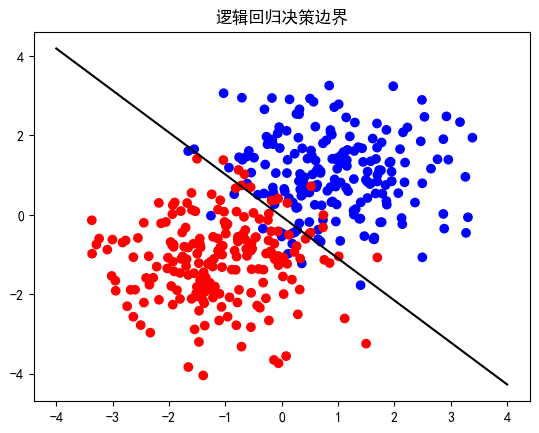

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. 生成数据
np.random.seed(0)
X0 = np.random.randn(200, 2) + [1, 1]
X1 = np.random.randn(200, 2) + [-1, -1]
X = np.vstack((X0, X1))
y = np.hstack((np.zeros(200), np.ones(200)))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵损失
def loss(y_pred, y_true):
    return -np.mean(y_true*np.log(y_pred+1e-8)+(1-y_true)*np.log(1-y_pred+1e-8))

# 梯度下降法
w = np.zeros(2)
b = 0
lr = 0.1
iterations = 1000
for _ in range(iterations):
    z = X_train @ w + b
    y_pred = sigmoid(z)
    dz = y_pred - y_train
    dw = X_train.T @ dz / len(X_train)
    db = np.mean(dz)
    w -= lr * dw
    b -= lr * db

# 测试
z_test = X_test @ w + b
y_pred_test = (sigmoid(z_test) > 0.5).astype(int)
acc = np.mean(y_pred_test == y_test)
print("测试准确率：", acc)

# 绘制决策边界
x1 = np.linspace(-4, 4, 100)
x2 = -(w[0]*x1 + b) / w[1]
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.plot(x1, x2, 'k-')
plt.title('逻辑回归决策边界')
plt.show()